In [2]:
import uproot as up
import awkward as ak
import matplotlib.pyplot as plt
import vector as vec
import numpy as np
import pandas as pd

path = "/home/usuario/Madgraph/projects/gg_hh-LQs/"
signal = up.open(path + "signal/Events/run_01_decayed_1/tag_1_delphes_events.root")
sm = up.open("/home/usuario/Madgraph/projects/gg_hh-sm/Events/run_02_decayed_1/tag_1_delphes_events.root")
bg = up.open("/home/usuario/Madgraph/projects/gg_tth/Events/run_01/tag_1_delphes_events.root")

signal_tree = signal["Delphes"]
sm_tree = sm["Delphes"]
bg_tree = bg["Delphes"]

In [ ]:
def vector_builder(Signal, Particle_ID):

    pid = Signal["Particle.PID"].array()  #array con los ID de las particulas

    # Defino todos los arrays de las 4 componentes del cuatrivector

    pt = Signal["Particle.PT"].array() 

    px = Signal["Particle.Px"].array()
    py = Signal["Particle.Py"].array()
    pz = Signal["Particle.Pz"].array()
    E  = Signal["Particle.E"].array()

    # Extraigo la informacion para la particula seleccionada

    PT_particle = pt[pid == Particle_ID]

    px_particle = px[pid == Particle_ID]
    py_particle = py[pid == Particle_ID]
    pz_particle = pz[pid == Particle_ID]
    E_particle =  E[pid == Particle_ID]

    # Construyo el cuatrivector de la particula seleccionada
    # Aca estoy asumiendo que las particulas hijas de los higgs son las primeras en aparecer en el evento
    # REVISAR

    vect_particle= vec.zip({
        "px": px_particle[:,0], 
        "py": py_particle[:,0],
        "pz": pz_particle[:,0],
        "E":  E_particle[:,0],
        })

    return vect_particle, PT_particle




Analizamos el arbol, para seleccionar correctamente a las particulas hijas del Higgs

In [ ]:
# Aca uso la categoria Particle, de modo de obtener los decaimientos hasta el
# nivel de Pythia8. Si bien Delphes es quien arma el ROOT, en particles se guarda
# la informacion a nivel generacion. 

# Por otra parte, si uso Jet.LoQueBusque estoy haciendo un analisis a nivel reconstruccion
# de modo que ahi si es Delphes quien establece que cosa es o no una particula.

Particle_IDs = {
    "Higgs": 25,
    "b": 5,
    "b~": -5,
    "ta-": 15,
    "ta+": -15,
}

VLQ_Higgs, PTLQ_Higgs = vector_builder(signal_tree, Particle_IDs["Higgs"])
VLQ_b, PTLQ_b = vector_builder(signal_tree, Particle_IDs["b"])
VLQ_bbar, PTLQ_bbar = vector_builder(signal_tree, Particle_IDs["b~"])
VLQ_ta_minus, PTLQ_ta_minus = vector_builder(signal_tree, Particle_IDs["ta-"])
VLQ_ta_plus, PTLQ_ta_plus = vector_builder(signal_tree, Particle_IDs["ta+"])

VSM_Higgs, PTSM_Higgs = vector_builder(sm_tree, Particle_IDs["Higgs"])
VSM_b, PTSM_b = vector_builder(sm_tree, Particle_IDs["b"])
VSM_bbar, PTSM_bbar = vector_builder(sm_tree, Particle_IDs["b~"])
VSM_ta_minus, PTSM_ta_minus = vector_builder(sm_tree, Particle_IDs["ta-"])
VSM_ta_plus, PTSM_ta_plus = vector_builder(sm_tree, Particle_IDs["ta+"])

VBG_Higgs, PTBG_Higgs = vector_builder(bg_tree, Particle_IDs["Higgs"])
VBG_b, PTBG_b = vector_builder(bg_tree, Particle_IDs["b"])
VBG_bbar, PTBG_bbar = vector_builder(bg_tree, Particle_IDs["b~"])
VBG_ta_minus, PTBG_ta_minus = vector_builder(bg_tree, Particle_IDs["ta-"])
VBG_ta_plus, PTBG_ta_plus = vector_builder(bg_tree, Particle_IDs["ta+"])

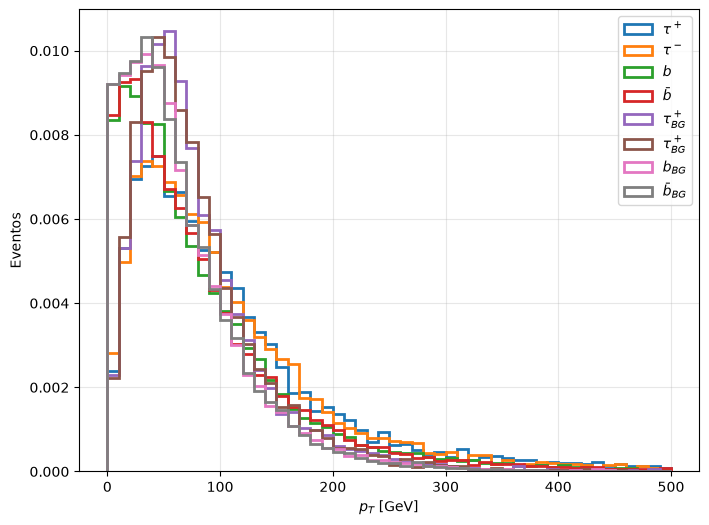

In [6]:
plt.figure(figsize=(8,6))

plt.hist(ak.to_numpy(ak.flatten(PTLQ_ta_plus)),bins=50, density = True,range=(0,500),histtype="step",linewidth=2,label=r"$\tau^+$")
plt.hist(ak.to_numpy(ak.flatten(PTLQ_ta_minus)),bins=50, density = True,range=(0,500),histtype="step",linewidth=2,label=r"$\tau^-$")
plt.hist(ak.to_numpy(ak.flatten(PTLQ_b)),bins=50, density = True,range=(0,500),histtype="step",linewidth=2,label=r"$b$")
plt.hist(ak.to_numpy(ak.flatten(PTLQ_bbar)),bins=50, density = True,range=(0,500),histtype="step",linewidth=2,label=r"$\bar{b}$")

plt.hist(ak.to_numpy(ak.flatten(PTBG_ta_plus)),bins=50, density = True,range=(0,500),histtype="step",linewidth=2,label=r"$\tau^+_{BG}$")
plt.hist(ak.to_numpy(ak.flatten(PTBG_ta_minus)),bins=50, density = True,range=(0,500),histtype="step",linewidth=2,label=r"$\tau^+_{BG}$")
plt.hist(ak.to_numpy(ak.flatten(PTBG_b)),bins=50, density = True,range=(0,500),histtype="step",linewidth=2,label=r"$b_{BG}$")
plt.hist(ak.to_numpy(ak.flatten(PTBG_bbar)),bins=50, density = True,range=(0,500),histtype="step",linewidth=2,label=r"$\bar{b}_{BG}$")

plt.xlabel(r"$p_T$ [GeV]")
plt.ylabel("Eventos")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("pt_distribution.png", dpi=300)

plt.show()

# Masas Invariantes

In [ ]:
# Calculo las masas invariantes por parejas y de los 4 elementos:

# SIGNAL:
MLQ_tautau = (VLQ_ta_plus + VLQ_ta_minus).mass
MLQ_bb = (VLQ_b + VLQ_bbar).mass
MLQ_hh = (VLQ_ta_plus + VLQ_ta_minus + VLQ_b + VLQ_bbar).mass

# SM:
MSM_tautau = (VSM_ta_plus + VSM_ta_minus).mass
MSM_bb = (VSM_b + VSM_bbar).mass
MSM_hh = (VSM_ta_plus + VSM_ta_minus + VSM_b + VSM_bbar).mass

# BG:
MBG_tautau = (VBG_ta_plus + VBG_ta_minus).mass
MBG_bb = (VBG_b + VBG_bbar).mass
MBG_hh = (VBG_ta_plus + VBG_ta_minus + VBG_b + VBG_bbar).mass

In [ ]:
def calculo_rangos(lim_inf, lim_sup, data):

    if type(data) == list:

        total_events = sum(len(data_i) for data_i in data)

        debajo = sum(np.sum(data_i < lim_inf) for data_i in data)

        dentro = sum(
            np.sum((data_i >= lim_inf) & (data_i <= lim_sup))
            for data_i in data
        )

        encima = sum(np.sum(data_i > lim_sup) for data_i in data)

        p_debajo = 100 * debajo / total_events
        p_dentro = 100 * dentro / total_events
        p_encima = 100 * encima / total_events

        return lim_inf, lim_sup, p_debajo, p_dentro, p_encima

    else:

        return print("Error: data debe ser una lista de arrays de datos.")


    
data = [MBG_tautau]

lim_inf, lim_sup, p_debajo, p_dentro, p_encima = calculo_rangos(124, 126, data)


plt.figure(figsize=(8,6))

# Escribir porcentajes
texto = (
    f"Debajo de {lim_inf} GeV : {p_debajo:.2f}%\n"
    f"Dentro del rango : {p_dentro:.2f}%\n"
    f"Encima de {lim_sup} GeV : {p_encima:.2f}%"
)

plt.text(
    0.98, 0.97,
    texto,
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.85)
)

plt.hist(ak.to_numpy(MLQ_tautau),bins=50,range=(lim_inf,lim_sup), density = True,histtype="step",linewidth=2,label=r"M($\tau^+$ $\tau^-$) - LQ")
# plt.hist(ak.to_numpy(MLQ_bb),bins=50,range=(lim_inf,lim_sup), density = True,histtype="step",linewidth=2,label=r"M($b$ $\bar{b}$) - LQ")

plt.hist(ak.to_numpy(MSM_tautau),bins=50,range=(lim_inf,lim_sup), density = True,histtype="step",linewidth=2,label=r"M($\tau^+$ $\tau^-$) - SM")
# plt.hist(ak.to_numpy(MSM_bb),bins=50,range=(lim_inf,lim_sup), density = True,histtype="step",linewidth=2,label=r"M($b$ $\bar{b}$) - SM")

plt.hist(ak.to_numpy(MBG_tautau),bins=50,range=(lim_inf,lim_sup), density = True, histtype="step",linewidth=2,label=r"M($\tau^+$ $\tau^-$) - BG")
# plt.hist(ak.to_numpy(MBG_bb),bins=50,range=(lim_inf,lim_sup), density = True,histtype="step",linewidth=2,label=r"M($b$ $\bar{b}$) - BG")

plt.xlabel(r"$M$ [GeV]")
plt.ylabel("Eventos")
plt.legend()
plt.grid(alpha=0.3)

plt.savefig("mass_distribution.png", dpi=300)

plt.show()

Error: data debe ser una lista de arrays de datos.


TypeError: cannot unpack non-iterable NoneType object

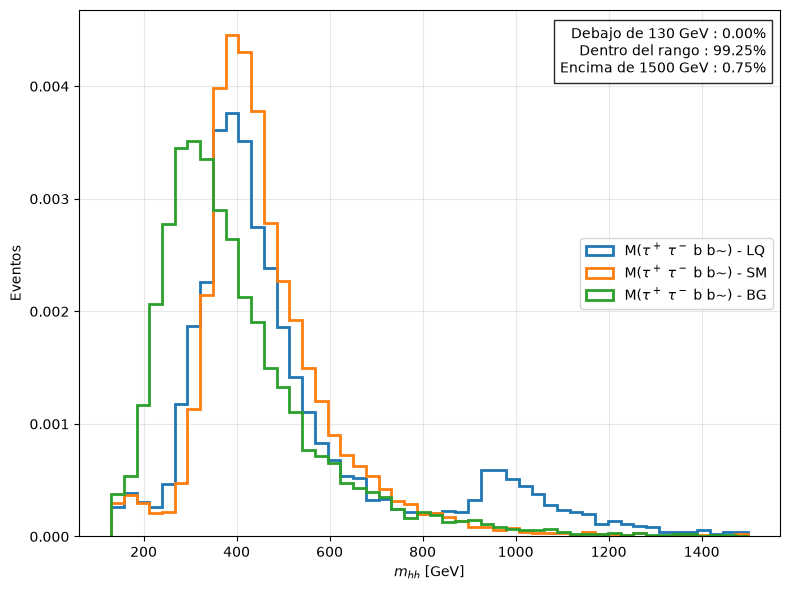

In [12]:
# Definir rango
lim_inf = 130
lim_sup = 1500

# Calcular porcentajes
N = len(MLQ_hh)

debajo = np.sum(MLQ_hh < lim_inf)
dentro = np.sum((MLQ_hh >= lim_inf) & (MLQ_hh <= lim_sup))
encima = np.sum(MLQ_hh > lim_sup)

p_debajo = 100 * debajo / N
p_dentro = 100 * dentro / N
p_encima = 100 * encima / N

# Histograma
plt.figure(figsize=(8,6))

plt.hist(
    MLQ_hh,
    bins=50,
    range=(lim_inf, lim_sup),
    density=True,
    histtype="step",
    linewidth=2,
    label = r"M($\tau^+$ $\tau^-$ b b~) - LQ"
)

plt.hist(
    MSM_hh,
    bins=50,
    range=(lim_inf, lim_sup),
    density=True,
    histtype="step",
    linewidth=2,
    label = r"M($\tau^+$ $\tau^-$ b b~) - SM"
)

plt.hist(
    MBG_hh,
    bins=50,
    range=(lim_inf, lim_sup),
    density=True,
    histtype="step",
    linewidth=2,
    label = r"M($\tau^+$ $\tau^-$ b b~) - BG"
)

plt.xlabel(r"$m_{hh}$ [GeV]")
plt.ylabel("Eventos")
plt.legend()

# Escribir porcentajes
texto = (
    f"Debajo de {lim_inf} GeV : {p_debajo:.2f}%\n"
    f"Dentro del rango : {p_dentro:.2f}%\n"
    f"Encima de {lim_sup} GeV : {p_encima:.2f}%"
)

plt.text(
    0.98, 0.97,
    texto,
    transform=plt.gca().transAxes,
    ha="right",
    va="top",
    bbox=dict(facecolor="white", alpha=0.85)
)

plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("hh_mass_distribution.png", dpi=300)

plt.show()

# Delta R

In [13]:
DeltaR_LQ_tautau = VLQ_ta_minus.deltaR(VLQ_ta_plus)
DeltaR_LQ_bb = VLQ_b.deltaR(VLQ_bbar)

DeltaR_SM_tautau = VSM_ta_minus.deltaR(VSM_ta_plus)
DeltaR_SM_bb = VSM_b.deltaR(VSM_bbar)

DeltaR_BG_tautau = VBG_ta_minus.deltaR(VBG_ta_plus)
DeltaR_BG_bb = VBG_b.deltaR(VBG_bbar)

In [66]:
list_taus_u600 = []
list_bs_u600 = []

list_taus_o800 = []
list_bs_o800 = []

for vec_tau, vec_antitau, vec_b, vec_antib in zip(VLQ_ta_minus, VLQ_ta_plus, VLQ_b, VLQ_bbar):

    M = (vec_tau + vec_antitau + vec_b + vec_antib).mass

    if 200 < M < 600:

        DeltaR_tautau_200_600 = vec_tau.deltaR(vec_antitau)
        DeltaR_bb_200_600 = vec_b.deltaR(vec_antib)

        list_taus_u600.append(DeltaR_tautau_200_600)
        list_bs_u600.append(DeltaR_bb_200_600)

    elif 800 < M < 1200:

        DeltaR_tautau_800_1200 = vec_tau.deltaR(vec_antitau)
        DeltaR_bb_800_1200 = vec_b.deltaR(vec_antib)

        list_taus_o800.append(DeltaR_tautau_800_1200)
        list_bs_o800.append(DeltaR_bb_800_1200)

Como el código tarda unos minutos, ya guardo en un .dat:

In [67]:
# Guardar región 200 < M < 600 GeV
data_u600 = np.column_stack((
    list_taus_u600,
    list_bs_u600
))

np.savetxt(
    "DeltaR_200_600.dat",
    data_u600,
    header="DeltaR_tautau    DeltaR_bb",
    fmt="%.6f"
)


# Guardar región 800 < M < 1200 GeV
data_o800 = np.column_stack((
    list_taus_o800,
    list_bs_o800
))

np.savetxt(
    "DeltaR_800_1200.dat",
    data_o800,
    header="DeltaR_tautau    DeltaR_bb",
    fmt="%.6f"
)

In [14]:
list_u600 = pd.pandas.read_csv("DeltaR_200_600.dat", comment="#", sep = r"\s+", names=["DeltaR_tautau", "DeltaR_bb"])
list_o800 = pd.pandas.read_csv("DeltaR_800_1200.dat", comment="#", sep = r"\s+", names=["DeltaR_tautau", "DeltaR_bb"])

taus_u600 = list_u600["DeltaR_tautau"].values
taus_o800 = list_o800["DeltaR_tautau"].values

b_u600 = list_u600["DeltaR_bb"].values
b_o800 = list_o800["DeltaR_bb"].values


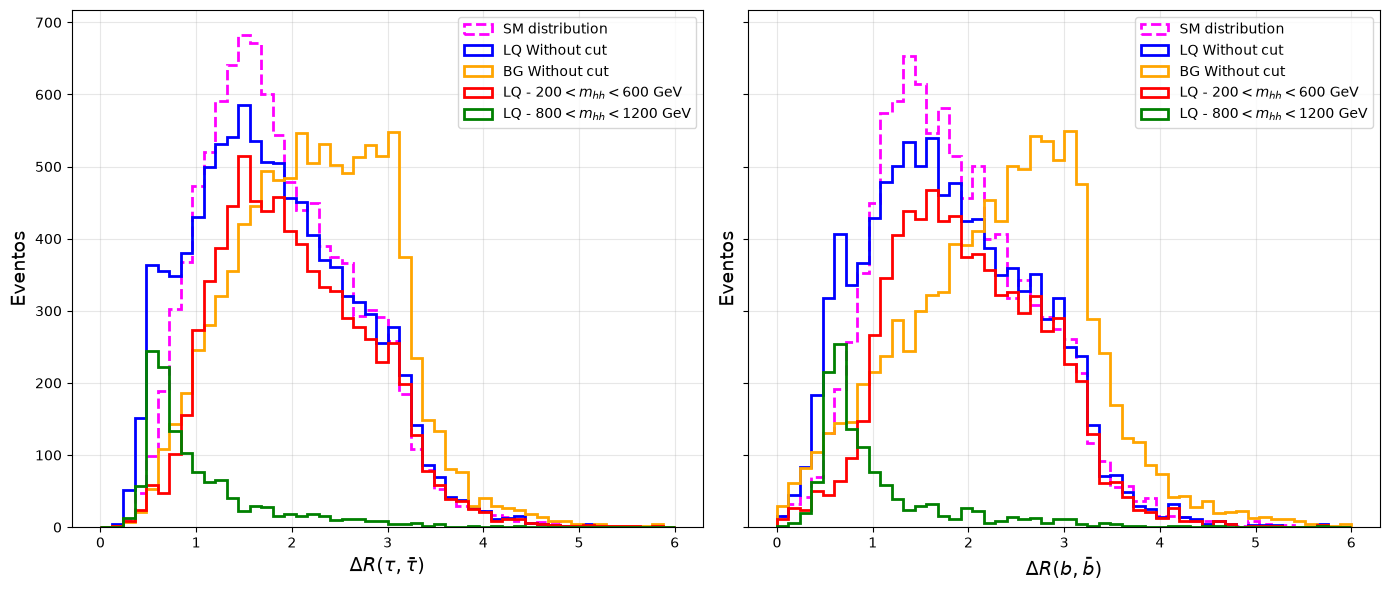

In [16]:

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14,6), sharey=True)

# ==========================================================
# Primer gráfico
# ==========================================================

ax1.hist(
    ak.to_numpy(DeltaR_SM_tautau),
    bins=50,
    range=(0,6),
    histtype="step",
    color="magenta",
    linestyle="--",
    linewidth=2,
    label="SM distribution"
)

ax1.hist(
    ak.to_numpy(DeltaR_LQ_tautau),
    bins=50,
    range=(0,6),
    histtype="step",
    color="blue",
    linewidth=2,
    label="LQ Without cut"
)

ax1.hist(
    ak.to_numpy(DeltaR_BG_tautau),
    bins=50,
    range=(0,6),
    histtype="step",
    color="orange",
    linewidth=2,
    label="BG Without cut"
)

ax1.hist(
    taus_u600,
    bins=50,
    range=(0,6),
    histtype="step",
    color="red",
    linewidth=2,
    label=r"LQ - $200<m_{hh}<600$ GeV"
)

ax1.hist(
    taus_o800,
    bins=50,
    range=(0,6),
    histtype="step",
    color="green",
    linewidth=2,
    label=r"LQ - $800<m_{hh}<1200$ GeV"
)

ax1.set_xlabel(r"$\Delta R(\tau,\bar \tau)$", fontsize=14)
ax1.set_ylabel("Eventos", fontsize=14)
ax1.grid(alpha=0.3)
ax1.legend(fontsize=10)

# ==========================================================
# Segundo gráfico
# ==========================================================

ax2.hist(
    ak.to_numpy(DeltaR_SM_bb),
    bins=50,
    range=(0,6),
    histtype="step",
    color="magenta",
    linestyle="--",
    linewidth=2,
    label="SM distribution"
)

ax2.hist(
    ak.to_numpy(DeltaR_LQ_bb),
    bins=50,
    range=(0,6),
    histtype="step",
    color="blue",
    linewidth=2,
    label="LQ Without cut"
)

ax2.hist(
    ak.to_numpy(DeltaR_BG_bb),
    bins=50,
    range=(0,6),
    histtype="step",
    color="orange",
    linewidth=2,
    label="BG Without cut"
)

ax2.hist(
    b_u600,
    bins=50,
    range=(0,6),
    histtype="step",
    color="red",
    linewidth=2,
    label=r"LQ - $200<m_{hh}<600$ GeV"
)

ax2.hist(
    b_o800,
    bins=50,
    range=(0,6),
    histtype="step",
    color="green",
    linewidth=2,
    label=r"LQ - $800<m_{hh}<1200$ GeV"
)

ax2.set_xlabel(r"$\Delta R(b,\bar b)$", fontsize=14)
ax2.set_ylabel("Eventos", fontsize=14)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=10)

# ==========================================================
# Ajustes finales
# ==========================================================

plt.tight_layout()

plt.savefig("DeltaR_distribution.png", dpi=300)

plt.show()